# 04. Modelo Predictivo 03 - Predecir si la respuesta de la compañía llegará a tiempo

## Librerias

In [21]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt
import seaborn as sns
from math import sqrt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, KFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import os








## Carga del dataset limpio

In [2]:
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_17136\93421454.py:1: SyntaxWarning: invalid escape sequence '\d'
  dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


In [3]:
X = dt_quejas.drop(columns=[
    'Difference in days', 
    'Complaint ID', 
    'Date received', 
    'Date sent to company', 'ZIP code', 'Company'
])
y = dt_quejas['Difference in days']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
categorical_features = X.select_dtypes(include='object').columns.tolist()
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [6]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Product', 'Sub-product',
                                                   'Issue', 'State',
                                                   'Company response',
                                                   'Timely response?',
                                                   'Consumer disputed?',
                                                   'Company_grouped_filtered'])])),
                ('regressor', LinearRegression())])

In [7]:
y_pred = pipe.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


MAE: 3.12
RMSE: 5.18
R²: 0.0937


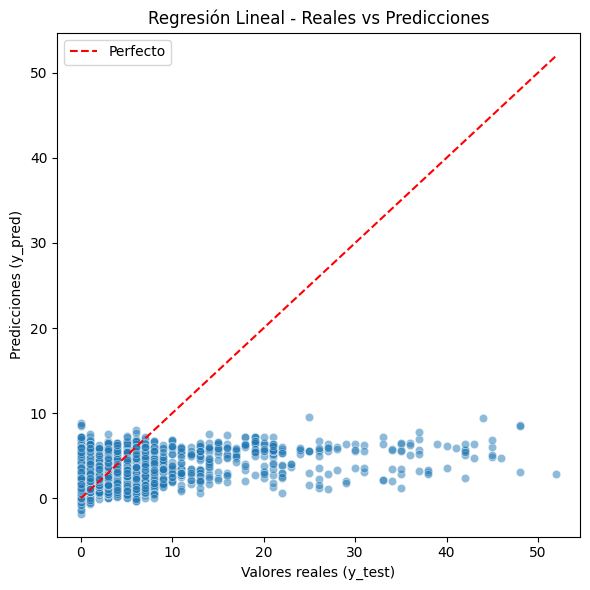

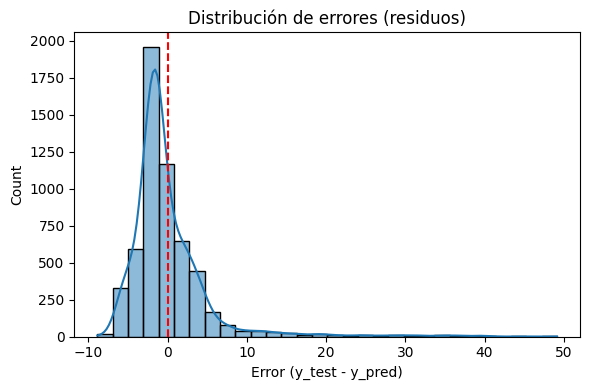

In [8]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label="Perfecto")
plt.xlabel("Valores reales (y_test)")
plt.ylabel("Predicciones (y_pred)")
plt.title("Regresión Lineal - Reales vs Predicciones")
plt.legend()
plt.tight_layout()
plt.show()


errors = y_test - y_pred
plt.figure(figsize=(6,4))
sns.histplot(errors, bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.xlabel("Error (y_test - y_pred)")
plt.title("Distribución de errores (residuos)")
plt.tight_layout()
plt.show()

In [9]:
def entrenar_rf_regresor(dt_quejas, drop_zip=True, random_state=42):

    y = pd.to_numeric(dt_quejas['Difference in days'], errors='coerce').fillna(0)
    cols_a_quitar = ['Difference in days', 'Complaint ID', 'Date received', 'Date sent to company', 'Company','ZIP code']

    X = dt_quejas.drop(columns=[c for c in cols_a_quitar if c in dt_quejas.columns]).copy()

    cat_cols = X.select_dtypes(include='object').columns.tolist()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    preprocessor = ColumnTransformer(
        transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
        remainder='passthrough'
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(random_state=random_state, n_jobs=-1))
    ])

    param_grid = {
        'rf__n_estimators': [300, 500],
        'rf__max_depth': [None, 10, 20],
        'rf__min_samples_split': [2, 5, 10],
        'rf__min_samples_leaf': [1, 2, 5],
        'rf__max_features': ['sqrt', 'log2']
    }

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=5,
        n_jobs=-1,
        verbose=1,
        refit=True
    )

    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    y_pred = best_model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("\nMejores parámetros:", grid.best_params_)
    print(f"Mejor MAE (CV): {-grid.best_score_:.3f}")

    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5)
    lim_min = min(y_test.min(), y_pred.min())
    lim_max = max(y_test.max(), y_pred.max())
    plt.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', label='Perfecto')
    plt.xlabel("Valores reales (y_test)")
    plt.ylabel("Predicciones (y_pred)")
    plt.title("RandomForest Regressor - Reales vs Predicciones")
    plt.legend()
    plt.tight_layout()
    plt.show()

    residuos = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(residuos, bins=40, kde=True)
    plt.axvline(0, color='r', linestyle='--')
    plt.xlabel("Error (y_test - y_pred)")
    plt.title("Distribución de errores (residuos)")
    plt.tight_layout()
    plt.show()

    return best_model, grid

Fitting 5 folds for each of 108 candidates, totalling 540 fits
MAE:  3.107
RMSE: 5.149
R²:   0.1041

Mejores parámetros: {'rf__max_depth': None, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 10, 'rf__n_estimators': 500}
Mejor MAE (CV): 3.133


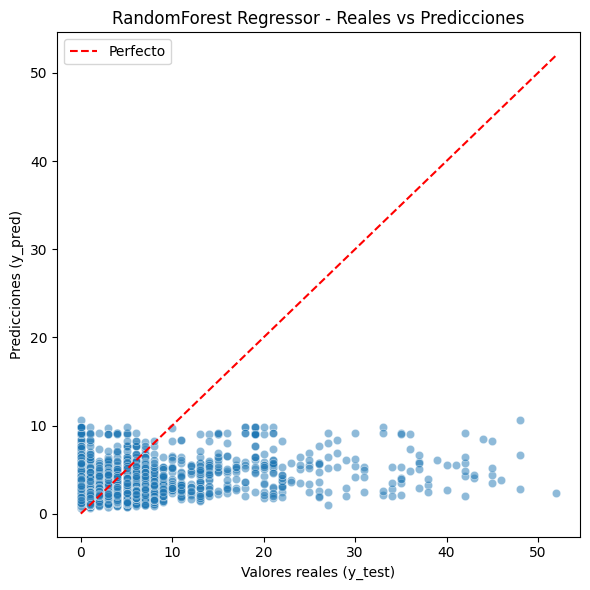

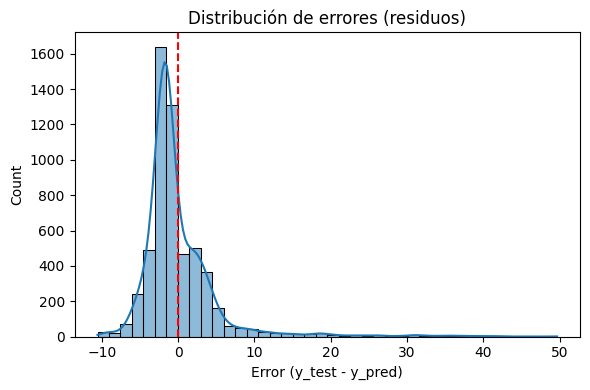

In [10]:
best_rf_reg, grid_rf_reg = entrenar_rf_regresor(dt_quejas)


In [11]:
def entrenar_xgb_regresor(dt_quejas, random_state=42):
    # --- columnas a quitar de X (tal cual pediste)
    cols_a_quitar = ['Difference in days', 'Complaint ID', 'Date received',
                     'Date sent to company', 'Company', 'ZIP code']

    # --- objetivo
    y = pd.to_numeric(dt_quejas['Difference in days'], errors='coerce').fillna(0)

    # --- features
    X = dt_quejas.drop(columns=[c for c in cols_a_quitar if c in dt_quejas.columns]).copy()

    # detectar tipos
    cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

    # preprocesado
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
        ],
        remainder='drop'
    )

    # modelo
    xgb = XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        random_state=random_state,
        n_jobs=-1
    )

    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('reg', xgb)
    ])

    # grid razonable
    param_grid = {
        'reg__n_estimators': [300, 500],
        'reg__max_depth': [3, 5, 7],
        'reg__learning_rate': [0.05, 0.1],
        'reg__subsample': [0.8, 1.0],
        'reg__colsample_bytree': [0.8, 1.0],
    }

    # split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # log-transform en y
    y_train_log = np.log1p(y_train)
    y_test_log  = np.log1p(y_test)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=5, n_jobs=-1, verbose=1, refit=True
    )

    grid.fit(X_train, y_train_log)
    best_model = grid.best_estimator_

    # predicción y vuelta de log
    y_pred_log = best_model.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    # métricas
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f"MAE:  {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R²:   {r2:.4f}")
    print("\nMejores parámetros:", grid.best_params_)
    print("Mejor MAE (CV):", -grid.best_score_)

    # --- gráficos ---
    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    max_ax = max(y_test.max(), y_pred.max())
    plt.plot([0, max_ax], [0, max_ax], 'r--', label='Perfecto')
    plt.xlabel('Valores reales (y_test)')
    plt.ylabel('Predicciones (y_pred)')
    plt.title('XGBoost Regressor - Reales vs Predicciones')
    plt.legend(); plt.tight_layout(); plt.show()

    resid = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(resid, bins=50, kde=True)
    plt.axvline(0, color='r', linestyle='--')
    plt.xlabel('Error (y_test - y_pred)')
    plt.title('Distribución de errores (residuos)')
    plt.tight_layout(); plt.show()

    return best_model, grid

Fitting 5 folds for each of 48 candidates, totalling 240 fits
MAE:  2.739
RMSE: 5.453
R²:   -0.0048

Mejores parámetros: {'reg__colsample_bytree': 0.8, 'reg__learning_rate': 0.05, 'reg__max_depth': 7, 'reg__n_estimators': 500, 'reg__subsample': 0.8}
Mejor MAE (CV): 0.747447932957226


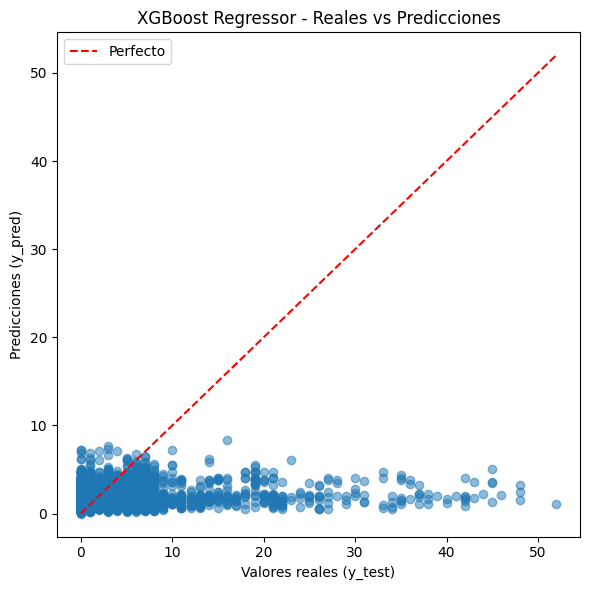

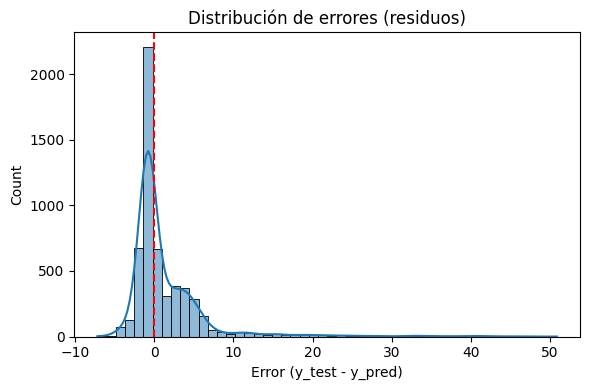

In [12]:
best_xgb_reg, grid_xgb_reg = entrenar_xgb_regresor(dt_quejas)


Dados los resultados vamos a probar un modelo de clasificacion en rangos. 

In [13]:
def categorizar_dias(x):
    if x <= 2:
        return 0
    elif x <= 7:
        return 1
    elif x <= 14:
        return 2
    else:
        return 3

dt_quejas["Delay_Class"] = dt_quejas["Difference in days"].apply(categorizar_dias)

In [14]:
cols_quitar = ['Difference in days','Complaint ID','Date received','Date sent to company','Company','ZIP code','Delay_Class']
X = dt_quejas.drop(columns=cols_quitar, errors='ignore')
y = dt_quejas['Delay_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
cat_cols = X.select_dtypes(include='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)

pipe = Pipeline(steps=[
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

param_grid = {
    'clf__n_estimators': [200, 500],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='f1_macro',  
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
print("Mejores parámetros:", grid.best_params_)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights='quadratic'))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores parámetros: {'clf__max_depth': 20, 'clf__min_samples_leaf': 1, 'clf__min_samples_split': 2, 'clf__n_estimators': 500}

Classification report:
               precision    recall  f1-score   support

           0       0.74      0.64      0.69      3590
           1       0.52      0.38      0.44      1623
           2       0.08      0.24      0.12       214
           3       0.16      0.56      0.25       205

    accuracy                           0.55      5632
   macro avg       0.38      0.45      0.37      5632
weighted avg       0.63      0.55      0.58      5632

Matriz de confusión:
 [[2303  484  372  431]
 [ 686  616  187  134]
 [  75   49   51   39]
 [  33   26   32  114]]
Quadratic Weighted Kappa: 0.204760680313255


In [16]:
cat_cols = X_train.select_dtypes(include="object").columns
num_cols = X_train.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=42)),
    ("clf", RandomForestClassifier(random_state=42))
])

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [10, 20, None],
    "clf__min_samples_split": [2, 5],
    "clf__min_samples_leaf": [1, 2]
}

grid = GridSearchCV(pipeline, param_grid, scoring="f1_macro", cv=5, n_jobs=-1)
grid.fit(X_train, y_train)



GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index([], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Product', 'Sub-product', 'Issue', 'State', 'Company response',
       'Timely response?', 'Consumer disputed?', 'Company_grouped_filtered'],
      dtype='object'))])),
                                       ('smote', SMOTE(random_state=42)),
                                       ('clf',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'clf__max_depth': [10, 20, None],
                         'clf__min_samples_leaf': [1, 2],
                         'clf__min_samples_split': [2, 5],
                         'clf__n_estimators': [200, 500]},
             scoring='f1_macro')

In [17]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print("Mejores parámetros:", grid.best_params_)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("Quadratic Weighted Kappa:", cohen_kappa_score(y_test, y_pred, weights='quadratic'))

Mejores parámetros: {'clf__max_depth': None, 'clf__min_samples_leaf': 2, 'clf__min_samples_split': 5, 'clf__n_estimators': 200}

Classification report:
               precision    recall  f1-score   support

           0       0.72      0.77      0.74      3590
           1       0.52      0.37      0.43      1623
           2       0.08      0.07      0.07       214
           3       0.19      0.48      0.27       205

    accuracy                           0.61      5632
   macro avg       0.38      0.42      0.38      5632
weighted avg       0.62      0.61      0.61      5632

Matriz de confusión:
 [[2747  468   85  290]
 [ 880  596   57   90]
 [ 111   57   14   32]
 [  70   26   11   98]]
Quadratic Weighted Kappa: 0.23931130270539314


In [18]:
cols_quitar = ['Difference in days','Complaint ID','Date received','Date sent to company','Company','ZIP code','Delay_Class']
X = dt_quejas.drop(columns=cols_quitar, errors='ignore')
y = dt_quejas['Delay_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

cat_cols = X_train.select_dtypes(include='object').columns.tolist()
num_cols = X_train.select_dtypes(exclude='object').columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cat_cols),
        ('num', 'passthrough', num_cols)
    ]
)

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    use_label_encoder=False,
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "clf__n_estimators": [200, 500],
    "clf__max_depth": [5, 10, 20],
    "clf__learning_rate": [0.05, 0.1],
    "clf__subsample": [0.8, 1.0],
    "clf__colsample_bytree": [0.8, 1.0]
}

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", xgb)
])

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",   
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:", grid.best_params_)

best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 48 candidates, totalling 144 fits


c:\Users\Jon\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [16:20:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mejores parámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.05, 'clf__max_depth': 10, 'clf__n_estimators': 500, 'clf__subsample': 0.8}

Classification report:
               precision    recall  f1-score   support

           0       0.69      0.92      0.79      3590
           1       0.59      0.31      0.41      1623
           2       0.27      0.01      0.03       214
           3       0.40      0.09      0.15       205

    accuracy                           0.68      5632
   macro avg       0.49      0.33      0.34      5632
weighted avg       0.64      0.68      0.63      5632


Matriz de confusión:
 [[3286  281    3   20]
 [1111  500    5    7]
 [ 166   44    3    1]
 [ 166   20    0   19]]


In [19]:
cols_quitar = ['Difference in days','Complaint ID','Date received','Date sent to company','Company','ZIP code','Delay_Class']
X = dt_quejas.drop(columns=cols_quitar, errors='ignore')
y = dt_quejas['Delay_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

cat_cols = X_train.select_dtypes(include="object").columns.tolist()
num_cols = X_train.select_dtypes(exclude="object").columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_pre, y_train)

xgb = XGBClassifier(
    objective="multi:softmax",   # multiclase
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

param_dist = {
    "n_estimators": [200, 500],
    "max_depth": [5, 10, 20],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rs = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=48,
    scoring="f1_macro",
    cv=3,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

rs.fit(X_train_bal, y_train_bal)
y_pred = rs.predict(X_test_pre)

print("Mejores parámetros:", rs.best_params_)
print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nMatriz de confusión:\n", confusion_matrix(y_test, y_pred))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Mejores parámetros: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 20, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Classification report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.76      3590
           1       0.54      0.35      0.43      1623
           2       0.12      0.04      0.06       214
           3       0.21      0.35      0.26       205

    accuracy                           0.64      5632
   macro avg       0.40      0.39      0.38      5632
weighted avg       0.62      0.64      0.62      5632


Matriz de confusión:
 [[2963  401   33  193]
 [ 979  568   19   57]
 [ 138   50    8   18]
 [ 100   25    8   72]]


In [22]:
ruta = r"C:\Users\Jon\Documents\Repositorios\Proyectos_DS2025\Proyecto Fin de Modulo ML\data"
os.makedirs(ruta, exist_ok=True)

dt_quejas.to_csv(os.path.join(ruta, "dt_quejas_modelo.csv"), index=False)